# Exploratory data analysis
- +15.000 records of weather and fine particle matter from 2025-01-01 to 2026-10-01

In [74]:
from supabase import create_client, Client
import os
from dotenv import load_dotenv
import pandas as pd
import time

load_dotenv()

url = os.getenv("SUPABASE_URL")
key = os.getenv("SUPABASE_KEY")
client = create_client(url,key)

all_records = []
batch_size = 1000
offset = 0
# Getting the data from supabase view
print("Iniciando extracción de datos desde Supabase...")

while True:
    response = client.table("vw_air_quality_features").select("*").range(offset, offset + batch_size - 1).execute()
    
    data_chunk = response.data
    
    if not data_chunk:
        break
    
    all_records.extend(data_chunk)
    print(f"Extraidas {len(all_records)} filas...")
    
    if len(data_chunk) < batch_size:
        break
    
    offset += batch_size
    
    time.sleep(0.5)

df = pd.DataFrame(all_records)

df['datetime_utc'] = pd.to_datetime(df['datetime_utc'])

print(f"\nExtraccion finalizada, tamaño del DataFrame: {df.shape}")

Iniciando extracción de datos desde Supabase...
Extraidas 1000 filas...
Extraidas 2000 filas...
Extraidas 3000 filas...
Extraidas 4000 filas...
Extraidas 5000 filas...
Extraidas 6000 filas...
Extraidas 7000 filas...
Extraidas 8000 filas...
Extraidas 9000 filas...
Extraidas 10000 filas...
Extraidas 11000 filas...
Extraidas 12000 filas...
Extraidas 13000 filas...
Extraidas 14000 filas...
Extraidas 15000 filas...
Extraidas 15336 filas...

Extraccion finalizada, tamaño del DataFrame: (15336, 9)


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15336 entries, 0 to 15335
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   datetime_utc          15336 non-null  datetime64[us, UTC]
 1   pm25_value            13134 non-null  float64            
 2   pm1_value             13135 non-null  float64            
 3   temperature_2m        15336 non-null  float64            
 4   wind_speed_10m        15336 non-null  float64            
 5   wind_direction_10m    15336 non-null  float64            
 6   shortwave_radiation   15336 non-null  float64            
 7   relative_humidity_2m  15336 non-null  float64            
 8   precipitation         15336 non-null  float64            
dtypes: datetime64[us, UTC](1), float64(8)
memory usage: 1.1 MB


In [76]:
df.describe()

,pm25_value,pm1_value,temperature_2m,wind_speed_10m,wind_direction_10m,shortwave_radiation,relative_humidity_2m,precipitation
count,13134.000000,13135.000000,15336.000000,15336.000000,15336.000000,15336.000000,15336.000000,15336.000000
mean,22.007311,14.397025,16.398533,10.894414,159.663100,190.492436,73.403429,0.112878
std,30.262887,18.979757,7.191596,5.135493,102.820894,277.960558,18.341527,0.690745
min,0.000000,0.000000,-3.050000,0.000000,0.600000,0.000000,17.730000,0.000000
25%,3.980000,2.510000,11.050000,7.220000,70.300000,0.000000,60.157500,0.000000
50%,11.400000,7.810000,16.150000,10.320000,142.500000,3.000000,76.190000,0.000000
75%,29.200000,19.500000,21.550000,13.890000,242.300000,333.000000,89.270000,0.000000
max,400.000000,221.000000,37.650000,40.880000,360.000000,1084.000000,100.000000,19.300000


In [77]:
outliers = df[df["pm25_value"] > 300]
outliers.sort_values(by="pm25_value", ascending=True)

,datetime_utc,pm25_value,pm1_value,temperature_2m,wind_speed_10m,wind_direction_10m,shortwave_radiation,relative_humidity_2m,precipitation
4275,2025-06-28 03:00:00+00:00,306.0,180.0,3.45,6.20,25.8,0.0,78.99,0.0
4370,2025-07-02 02:00:00+00:00,307.0,185.0,-0.85,3.93,344.1,0.0,77.74,0.0
4373,2025-07-02 05:00:00+00:00,314.0,188.0,-2.30,6.34,325.4,0.0,81.72,0.0
4273,2025-06-28 01:00:00+00:00,315.0,190.0,3.75,7.34,36.0,0.0,71.92,0.0
4378,2025-07-02 10:00:00+00:00,315.0,179.0,-2.85,5.68,11.0,0.0,85.77,0.0
12096,2026-05-20 00:00:00+00:00,351.0,144.0,9.40,10.14,276.1,0.0,74.52,0.0
4375,2025-07-02 07:00:00+00:00,375.0,212.0,-2.85,5.86,317.5,0.0,84.80,0.0
4274,2025-06-28 02:00:00+00:00,379.0,221.0,3.50,7.00,25.9,0.0,77.02,0.0
4376,2025-07-02 08:00:00+00:00,386.0,215.0,-3.05,5.40,330.0,0.0,86.07,0.0
4377,2025-07-02 09:00:00+00:00,391.0,216.0,-3.00,5.25,354.1,0.0,86.08,0.0


- **PM2.5 values above 300 µg/m³ show a strong correlation with low temperatures, low wind speed and high relative humidity, all this conditions occur between argentinian's april and july (winter). Furthermore PM1 values are high compared to their average, indicating that both pm values are not merely outliers, but actual readings due to a possible thermal inversion**.

array([[<Axes: title={'center': 'datetime_utc'}>,
        <Axes: title={'center': 'pm25_value'}>,
        <Axes: title={'center': 'pm1_value'}>],
       [<Axes: title={'center': 'temperature_2m'}>,
        <Axes: title={'center': 'wind_speed_10m'}>,
        <Axes: title={'center': 'wind_direction_10m'}>],
       [<Axes: title={'center': 'shortwave_radiation'}>,
        <Axes: title={'center': 'relative_humidity_2m'}>,
        <Axes: title={'center': 'precipitation'}>]], dtype=object)

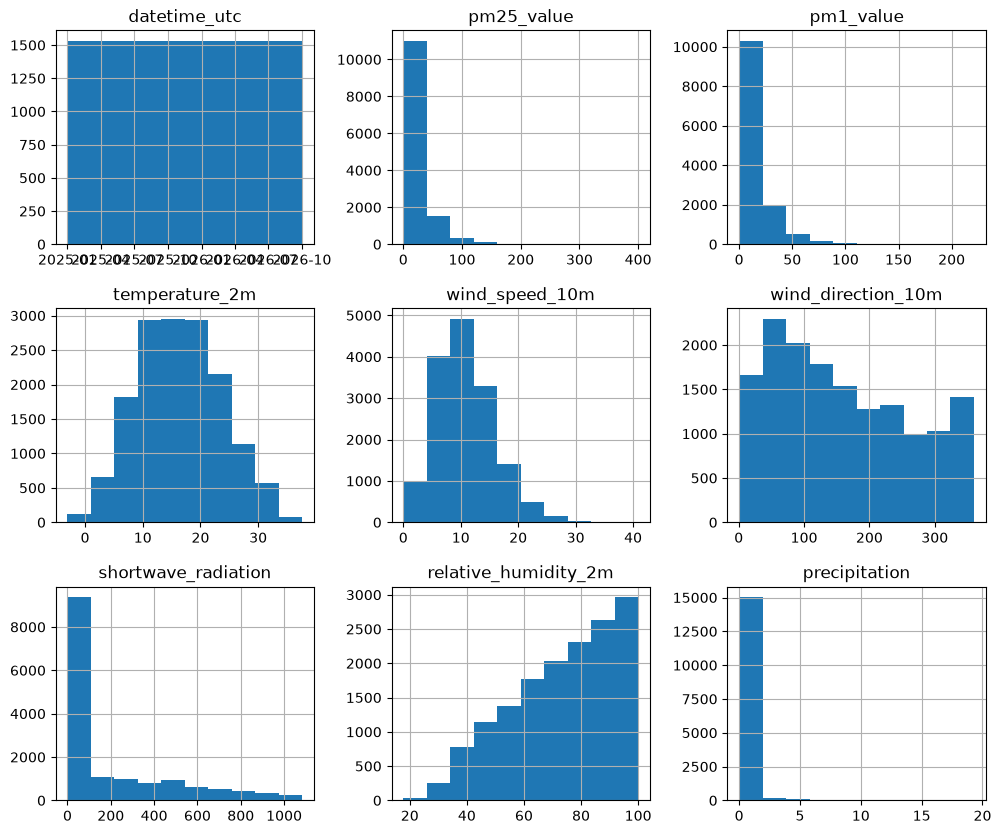

In [78]:
df.hist(figsize=(12,10))

In [79]:
df_clean = df.dropna(subset=['pm25_value', 'pm1_value']).copy()

- All weather records that did not include PM2.5 levels (approximately 2,000 rows) have been removed, since PM2.5 values cannot be randomly imputed given that this is an issue related to health and well-being.

In [80]:
import numpy as np

pm25_classes = [0,5,15,50,90,140,np.inf]

labels_eea = ["Good","Fair","Moderate","Poor","Very Poor", "Extremely Poor"]

df_clean["aqi_pm25"] = pd.cut(df_clean["pm25_value"],bins=pm25_classes,labels=labels_eea,include_lowest=True)

print(df_clean["aqi_pm25"].value_counts(normalize=True)*100)

aqi_pm25
Moderate          32.107507
Good              30.143140
Fair              26.770215
Poor               7.743262
Very Poor          2.124258
Extremely Poor     1.111619
Name: proportion, dtype: float64


<Axes: >

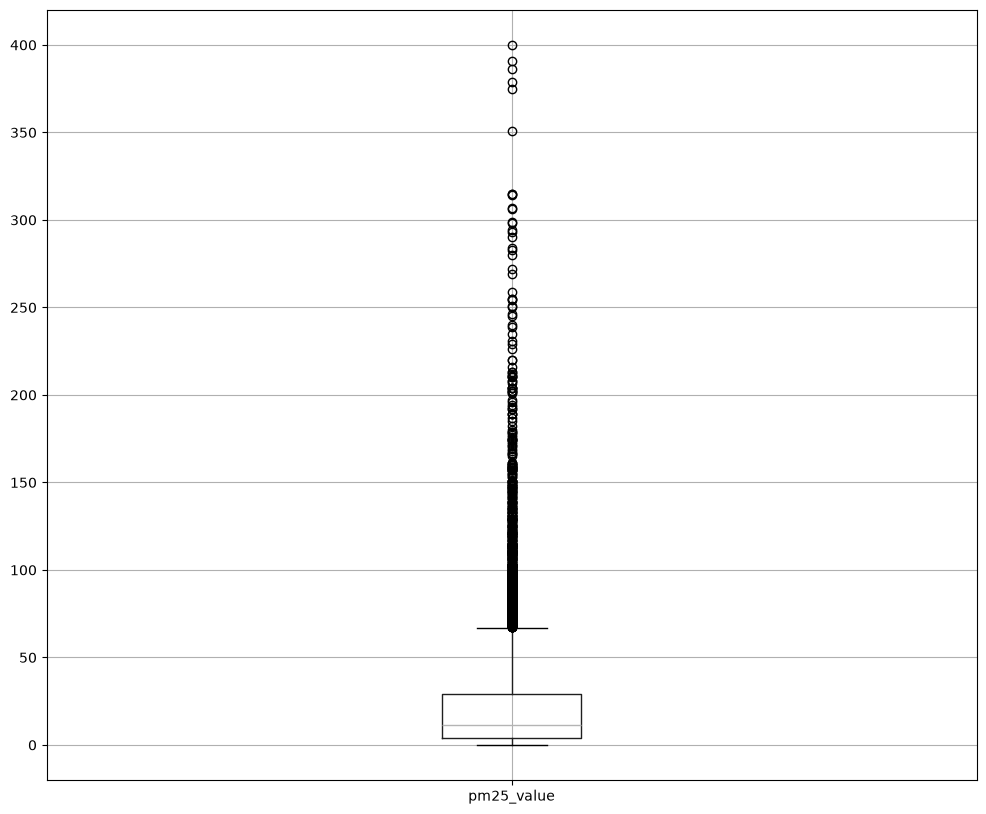

In [81]:
df_clean.boxplot(column=["pm25_value"],figsize=(12,10))

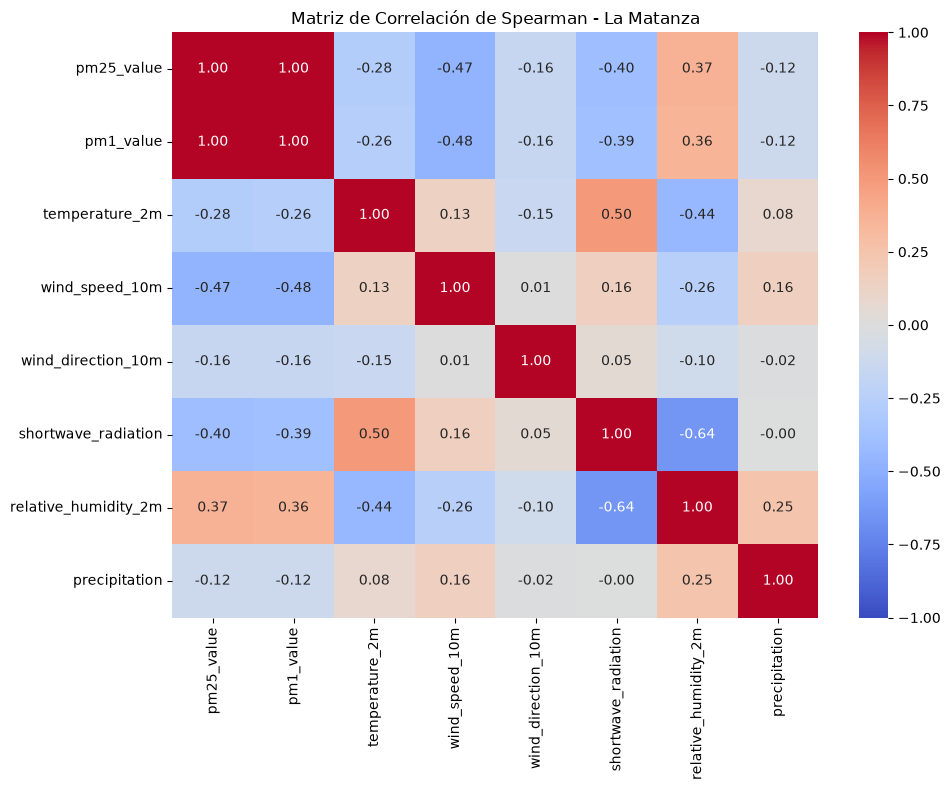

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_numericas = [
    'pm25_value', 'pm1_value', 'temperature_2m', 
    'wind_speed_10m', 'wind_direction_10m', 
    'shortwave_radiation', 'relative_humidity_2m', 'precipitation'
]

# Spearman because we do not have normal distributions
matriz_corr = df_clean[cols_numericas].corr(method='spearman')

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_corr, 
    annot=True,          
    cmap='coolwarm',     
    fmt=".2f",           
    vmin=-1, vmax=1      
)
plt.title("Matriz de Correlación de Spearman - La Matanza")
plt.tight_layout()
plt.show()


- Due to the 1.00 correlation between PM2.5 and PM1, i decided to remove all PM1 values to prevent the model from being affected by **data leakage** or **data snooping**.

In [83]:
df_cleaner = df_clean.drop(columns="pm1_value")

## Feature engineering

In [84]:
df_cleaner["datetime_local"] = df_cleaner["datetime_utc"].dt.tz_convert('America/Argentina/Buenos_Aires')

df_cleaner["hour"] = df_cleaner["datetime_local"].dt.hour
df_cleaner["day_of_week"] = df_cleaner["datetime_local"].dt.day_of_week
df_cleaner["month"] = df_cleaner["datetime_local"].dt.month
df_cleaner["year"] = df_cleaner["datetime_local"].dt.year

In [85]:
df_cleaner.head()

,datetime_utc,pm25_value,temperature_2m,wind_speed_10m,wind_direction_10m,shortwave_radiation,relative_humidity_2m,precipitation,aqi_pm25,datetime_local,hour,day_of_week,month,year
1,2025-01-01 01:00:00+00:00,75.0,23.85,10.37,69.7,0.0,64.49,0.0,Poor,2024-12-31 22:00:00-03:00,22,1,12,2024
2,2025-01-01 02:00:00+00:00,62.5,22.70,8.12,86.2,0.0,71.13,0.0,Poor,2024-12-31 23:00:00-03:00,23,1,12,2024
3,2025-01-01 03:00:00+00:00,66.4,21.65,6.19,98.4,0.0,78.50,0.0,Poor,2025-01-01 00:00:00-03:00,0,2,1,2025
4,2025-01-01 04:00:00+00:00,95.7,20.60,5.05,85.9,0.0,85.33,0.0,Very Poor,2025-01-01 01:00:00-03:00,1,2,1,2025
5,2025-01-01 05:00:00+00:00,70.0,20.30,5.07,83.9,0.0,87.47,0.0,Poor,2025-01-01 02:00:00-03:00,2,2,1,2025


In [86]:
df_cleaner = df_cleaner.drop(columns=['datetime_utc'])

df_cleaner.set_index('datetime_local',inplace=True)

df_cleaner = df_cleaner.asfreq('h')

df_cleaner['pm25_lag_1'] = df_cleaner['pm25_value'].shift(1)

In [87]:
df_cleaner.head()

,pm25_value,temperature_2m,wind_speed_10m,wind_direction_10m,shortwave_radiation,relative_humidity_2m,precipitation,aqi_pm25,hour,day_of_week,month,year,pm25_lag_1
datetime_local,,,,,,,,,,,,,
2024-12-31 22:00:00-03:00,75.0,23.85,10.37,69.7,0.0,64.49,0.0,Poor,22.0,1.0,12.0,2024.0,NaN
2024-12-31 23:00:00-03:00,62.5,22.70,8.12,86.2,0.0,71.13,0.0,Poor,23.0,1.0,12.0,2024.0,75.0
2025-01-01 00:00:00-03:00,66.4,21.65,6.19,98.4,0.0,78.50,0.0,Poor,0.0,2.0,1.0,2025.0,62.5
2025-01-01 01:00:00-03:00,95.7,20.60,5.05,85.9,0.0,85.33,0.0,Very Poor,1.0,2.0,1.0,2025.0,66.4
2025-01-01 02:00:00-03:00,70.0,20.30,5.07,83.9,0.0,87.47,0.0,Poor,2.0,2.0,1.0,2025.0,95.7


In [88]:
df_cleaner.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 15261 entries, 2024-12-31 22:00:00-03:00 to 2026-09-28 18:00:00-03:00
Freq: h
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   pm25_value            13134 non-null  float64 
 1   temperature_2m        13134 non-null  float64 
 2   wind_speed_10m        13134 non-null  float64 
 3   wind_direction_10m    13134 non-null  float64 
 4   shortwave_radiation   13134 non-null  float64 
 5   relative_humidity_2m  13134 non-null  float64 
 6   precipitation         13134 non-null  float64 
 7   aqi_pm25              13134 non-null  category
 8   hour                  13134 non-null  float64 
 9   day_of_week           13134 non-null  float64 
 10  month                 13134 non-null  float64 
 11  year                  13134 non-null  float64 
 12  pm25_lag_1            13133 non-null  float64 
dtypes: category(1), float64(12)
memory usage: 1.5 MB


In [89]:
import numpy as np

df_cleaner['wind_sin'] = np.sin(np.radians(df_cleaner['wind_direction_10m']))
df_cleaner['wind_cos'] = np.cos(np.radians(df_cleaner['wind_direction_10m']))

df_cleaner = df_cleaner.drop(columns=['wind_direction_10m'])

df_final = df_cleaner.dropna().copy()

df_final.info()


<class 'pandas.DataFrame'>
DatetimeIndex: 13061 entries, 2024-12-31 23:00:00-03:00 to 2026-09-28 18:00:00-03:00
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   pm25_value            13061 non-null  float64 
 1   temperature_2m        13061 non-null  float64 
 2   wind_speed_10m        13061 non-null  float64 
 3   shortwave_radiation   13061 non-null  float64 
 4   relative_humidity_2m  13061 non-null  float64 
 5   precipitation         13061 non-null  float64 
 6   aqi_pm25              13061 non-null  category
 7   hour                  13061 non-null  float64 
 8   day_of_week           13061 non-null  float64 
 9   month                 13061 non-null  float64 
 10  year                  13061 non-null  float64 
 11  pm25_lag_1            13061 non-null  float64 
 12  wind_sin              13061 non-null  float64 
 13  wind_cos              13061 non-null  float64 
dtypes: category(1), fl

In [90]:
df_final.head()

,pm25_value,temperature_2m,wind_speed_10m,shortwave_radiation,relative_humidity_2m,precipitation,aqi_pm25,hour,day_of_week,month,year,pm25_lag_1,wind_sin,wind_cos
datetime_local,,,,,,,,,,,,,,
2024-12-31 23:00:00-03:00,62.5,22.70,8.12,0.0,71.13,0.0,Poor,23.0,1.0,12.0,2024.0,75.0,0.997801,0.066274
2025-01-01 00:00:00-03:00,66.4,21.65,6.19,0.0,78.50,0.0,Poor,0.0,2.0,1.0,2025.0,62.5,0.989272,-0.146083
2025-01-01 01:00:00-03:00,95.7,20.60,5.05,0.0,85.33,0.0,Very Poor,1.0,2.0,1.0,2025.0,66.4,0.997441,0.071497
2025-01-01 02:00:00-03:00,70.0,20.30,5.07,0.0,87.47,0.0,Poor,2.0,2.0,1.0,2025.0,95.7,0.994338,0.106264
2025-01-01 03:00:00-03:00,46.7,20.50,4.94,0.0,86.94,0.0,Moderate,3.0,2.0,1.0,2025.0,70.0,0.983255,0.182236


In [91]:
df_final.iloc[:10448].head(10)

,pm25_value,temperature_2m,wind_speed_10m,shortwave_radiation,relative_humidity_2m,precipitation,aqi_pm25,hour,day_of_week,month,year,pm25_lag_1,wind_sin,wind_cos
datetime_local,,,,,,,,,,,,,,
2024-12-31 23:00:00-03:00,62.50,22.70,8.12,0.0,71.13,0.0,Poor,23.0,1.0,12.0,2024.0,75.00,0.997801,0.066274
2025-01-01 00:00:00-03:00,66.40,21.65,6.19,0.0,78.50,0.0,Poor,0.0,2.0,1.0,2025.0,62.50,0.989272,-0.146083
2025-01-01 01:00:00-03:00,95.70,20.60,5.05,0.0,85.33,0.0,Very Poor,1.0,2.0,1.0,2025.0,66.40,0.997441,0.071497
2025-01-01 02:00:00-03:00,70.00,20.30,5.07,0.0,87.47,0.0,Poor,2.0,2.0,1.0,2025.0,95.70,0.994338,0.106264
2025-01-01 03:00:00-03:00,46.70,20.50,4.94,0.0,86.94,0.0,Moderate,3.0,2.0,1.0,2025.0,70.00,0.983255,0.182236
2025-01-01 04:00:00-03:00,47.00,20.55,2.93,0.0,87.49,0.0,Moderate,4.0,2.0,1.0,2025.0,46.70,0.982935,0.183951
2025-01-01 05:00:00-03:00,23.10,20.30,5.23,0.0,88.02,0.0,Moderate,5.0,2.0,1.0,2025.0,47.00,0.653421,0.756995
2025-01-01 06:00:00-03:00,5.28,20.90,7.85,1.0,86.43,0.0,Fair,6.0,2.0,1.0,2025.0,23.10,0.596225,0.802817
2025-01-01 07:00:00-03:00,4.87,22.90,10.13,86.0,76.74,0.0,Good,7.0,2.0,1.0,2025.0,5.28,0.213030,0.977046


In [92]:
df_final['hour_sin'] = np.sin(2 * np.pi * df_final['hour'] / 24)
df_final['hour_cos'] = np.cos(2 * np.pi * df_final['hour'] / 24)

df_final['month_sin'] = np.sin(2 * np.pi * df_final['month'] / 12)
df_final['month_cos'] = np.cos(2 * np.pi * df_final['month'] / 12)

# Turn hour and month columns into ciclic variables

### Train, test split

In [93]:
aqi_mapping = {"Good": 0, "Fair": 1, "Moderate": 2, "Poor": 3, "Very Poor": 4, "Extremely Poor": 5}
df_final["aqi_25_encoded"] = df_final["aqi_pm25"].map(aqi_mapping).astype(int)

# Remove pm25_value to avoid data leakage
df_train_test = df_final.drop(columns=["pm25_value", "aqi_pm25", "hour", "month"])

split_idx = int(len(df_train_test) * 0.80)

X_train = df_train_test.iloc[:split_idx].drop(columns="aqi_25_encoded")
X_test = df_train_test.iloc[split_idx:].drop(columns="aqi_25_encoded")

y_train = df_train_test["aqi_25_encoded"].iloc[:split_idx]
y_test = df_train_test["aqi_25_encoded"].iloc[split_idx:]

In [94]:
y_train.head()

datetime_local
2024-12-31 23:00:00-03:00    3
2025-01-01 00:00:00-03:00    3
2025-01-01 01:00:00-03:00    4
2025-01-01 02:00:00-03:00    3
2025-01-01 03:00:00-03:00    2
Name: aqi_25_encoded, dtype: int64

In [95]:
X_train.head()

,temperature_2m,wind_speed_10m,shortwave_radiation,relative_humidity_2m,precipitation,day_of_week,year,pm25_lag_1,wind_sin,wind_cos,hour_sin,hour_cos,month_sin,month_cos
datetime_local,,,,,,,,,,,,,,
2024-12-31 23:00:00-03:00,22.70,8.12,0.0,71.13,0.0,1.0,2024.0,75.0,0.997801,0.066274,-0.258819,0.965926,-2.449294e-16,1.000000
2025-01-01 00:00:00-03:00,21.65,6.19,0.0,78.50,0.0,2.0,2025.0,62.5,0.989272,-0.146083,0.000000,1.000000,5.000000e-01,0.866025
2025-01-01 01:00:00-03:00,20.60,5.05,0.0,85.33,0.0,2.0,2025.0,66.4,0.997441,0.071497,0.258819,0.965926,5.000000e-01,0.866025
2025-01-01 02:00:00-03:00,20.30,5.07,0.0,87.47,0.0,2.0,2025.0,95.7,0.994338,0.106264,0.500000,0.866025,5.000000e-01,0.866025
2025-01-01 03:00:00-03:00,20.50,4.94,0.0,86.94,0.0,2.0,2025.0,70.0,0.983255,0.182236,0.707107,0.707107,5.000000e-01,0.866025


In [96]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier


standard_scaled_features = ["pm25_lag_1","temperature_2m","wind_speed_10m","shortwave_radiation","relative_humidity_2m","precipitation"]

transformer = ColumnTransformer([("scaler", StandardScaler(),standard_scaled_features)])

model = RidgeClassifier(class_weight='balanced', random_state=42)

base_pipeline = Pipeline([("column_transformer",transformer),
                          ("model", model)])


In [97]:
base_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('column_transformer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](6,)","[0,1,2,3,4,5]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['temperature_2m','wind_speed_10m','shortwave_radiation',...,'hour_cos', 'month_sin','month_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``re

In [98]:
from sklearn.metrics import classification_report

y_pred = base_pipeline.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.32      0.83      0.46       568
           1       0.32      0.03      0.05       711
           2       0.57      0.14      0.23       996
           3       0.21      0.58      0.31       259
           4       0.28      0.15      0.19        61
           5       0.17      0.89      0.28        18

    accuracy                           0.31      2613
   macro avg       0.31      0.44      0.25      2613
weighted avg       0.40      0.31      0.24      2613



- Baseline model shows us that linear solution simply pushes the intermediate labels such as "fair" and "very poor" toward both extremes in order to avoid doubt and predict a value.

In [99]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

transformer = ColumnTransformer([("scaler", StandardScaler(),standard_scaled_features)])

base_pipeline = Pipeline([("column_transformer",transformer),
                          ("model", model)])

base_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('column_transformer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](6,)","[0,1,2,3,4,5]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['temperature_2m','wind_speed_10m','shortwave_radiation',...,'hour_cos', 'month_sin','month_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``re

In [100]:
y_pred_2 = base_pipeline.predict(X_test)

print(classification_report(y_test,y_pred_2))

              precision    recall  f1-score   support

           0       0.77      0.83      0.80       568
           1       0.63      0.64      0.64       711
           2       0.79      0.72      0.75       996
           3       0.59      0.69      0.63       259
           4       0.45      0.31      0.37        61
           5       0.43      0.67      0.52        18

    accuracy                           0.71      2613
   macro avg       0.61      0.64      0.62      2613
weighted avg       0.71      0.71      0.71      2613



In [ ]:
transformer = ColumnTransformer([("scaler", StandardScaler(),standard_scaled_features)], remainder='passthrough')

model = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

base_pipeline = Pipeline([("column_transformer",transformer),
                          ("model", model)])

In [105]:
base_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('column_transformer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](6,)","[0,1,2,3,4,5]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['temperature_2m','wind_speed_10m','shortwave_radiation',...,'hour_cos', 'month_sin','month_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``re

In [106]:
y_pred_3 = base_pipeline.predict(X_test)

print(classification_report(y_test,y_pred_3))

              precision    recall  f1-score   support

           0       0.78      0.83      0.80       568
           1       0.67      0.61      0.64       711
           2       0.79      0.76      0.78       996
           3       0.59      0.80      0.68       259
           4       0.50      0.20      0.28        61
           5       0.50      0.50      0.50        18

    accuracy                           0.73      2613
   macro avg       0.64      0.62      0.61      2613
weighted avg       0.73      0.73      0.72      2613



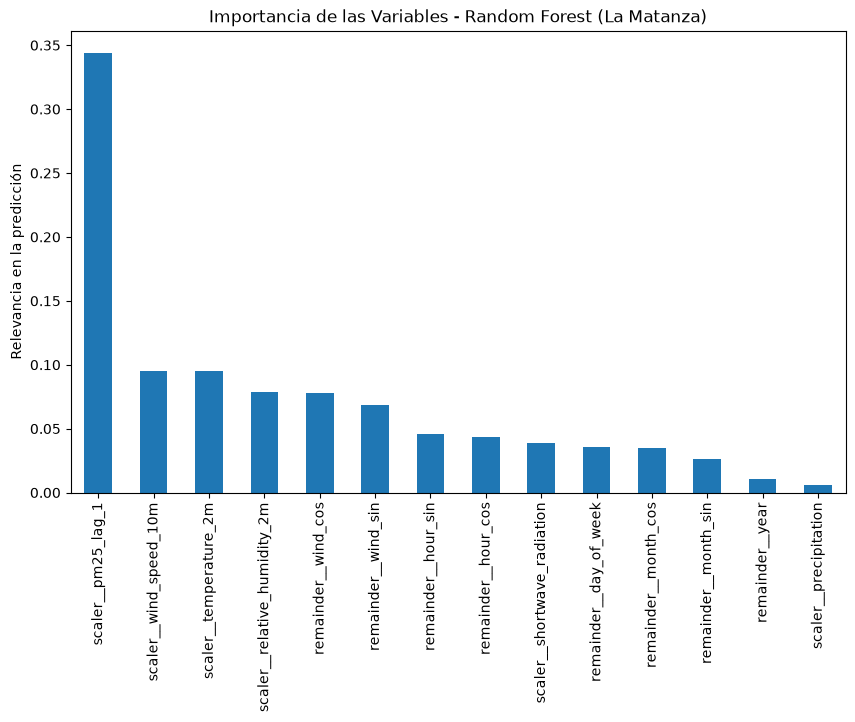

In [108]:
import matplotlib.pyplot as plt

rf_model = base_pipeline.named_steps['model']

feature_names = base_pipeline.named_steps['column_transformer'].get_feature_names_out()

importancias = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importancias.plot(kind='bar')
plt.title("Importancia de las Variables - Random Forest (La Matanza)")
plt.ylabel("Relevancia en la predicción")
plt.show()


In [111]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV

param_values = {
    "model__n_estimators": [100,200,300,400,500],
    "model__max_depth": [2,4,8,10,20, None],
    "model__min_samples_split": [2,3,4,5,6,7],
    "model__min_samples_leaf": [2,5,7,10]
}

tcv = TimeSeriesSplit(n_splits=5)

cross_val = RandomizedSearchCV(estimator=base_pipeline,
                               param_distributions=param_values,
                               cv=tcv, 
                               n_iter=20,
                               scoring="recall_macro",
                               n_jobs=1,
                               random_state=42)

cross_val.fit(X_train,y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [2, 4, ...], 'model__min_samples_leaf': [2, 5, ...], 'model__min_samples_split': [2, 3, ...], 'model__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict``

In [112]:
cross_val.best_params_

{'model__n_estimators': 100,
 'model__min_samples_split': 2,
 'model__min_samples_leaf': 5,
 'model__max_depth': 10}

In [114]:
from sklearn.metrics import classification_report

# 1. Ver la combinación ganadora de hiperparámetros
print("Mejores hiperparámetros encontrados:")
print(cross_val.best_params_)
print("-" * 50)

# 2. Ver qué puntaje de Recall Macro logró esa combinación durante el entrenamiento
print(f"Mejor score de CV (Recall Macro): {cross_val.best_score_:.4f}")
print("-" * 50)

# 3. La prueba de fuego: predecir sobre los datos del futuro
y_pred_tuned = cross_val.predict(X_test)

# 4. Imprimir el reporte para comparar con tu modelo por defecto
print("Reporte de Clasificación - Modelo Optimizado:")
print(classification_report(y_test, y_pred_tuned))

Mejores hiperparámetros encontrados:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 5, 'model__max_depth': 10}
--------------------------------------------------
Mejor score de CV (Recall Macro): 0.5935
--------------------------------------------------
Reporte de Clasificación - Modelo Optimizado:
              precision    recall  f1-score   support

           0       0.79      0.82      0.80       568
           1       0.65      0.64      0.64       711
           2       0.80      0.66      0.72       996
           3       0.51      0.76      0.61       259
           4       0.39      0.48      0.43        61
           5       0.43      0.72      0.54        18

    accuracy                           0.70      2613
   macro avg       0.59      0.68      0.62      2613
weighted avg       0.71      0.70      0.70      2613



In [116]:
cross_val_2 = RandomizedSearchCV(estimator=base_pipeline,
                               param_distributions=param_values,
                               cv=tcv, 
                               n_iter=20,
                               scoring="f1_macro",
                               n_jobs=1,
                               random_state=42)

cross_val_2.fit(X_train,y_train)

print(cross_val.best_params_)
print(cross_val_2.best_score_)

{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 5, 'model__max_depth': 10}
0.575751786531222


In [117]:
import joblib

prod_model = cross_val.best_estimator_

joblib.dump(prod_model, 'pipeline_air_quality.pkl')

print("Guardado exitosamente")

Guardado exitosamente
